# Software Engineer Compensation Prediction & Feature Attribution

## Problem Statement
The goal of this project is to predict the annual salary of software engineers and, more importantly, to quantify the tangible dollar value of various drivers like experience, education, specific technical skills, company size, and geographic location.

This analysis provides data-driven compensation insights that are actionable for both HR recruitment teams structuring offers and software engineers navigating career paths.


#### Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Fetch data

In [9]:
data = pd.read_csv(r"C:\Users\saika\AppData\Local\Claude-3p\local-agent-mode-sessions\f450fa87\00000000\4a3f6fa1\outputs\engineer_salary_prediction.csv")


#### Data Integrity and Anomaly Checks

In [10]:
print("Duplicate rows :",data.duplicated().sum())
print("Duplicate ID's :",data["employee_id"].duplicated().sum())

Duplicate rows : 0
Duplicate ID's : 7


In [11]:
data = data.drop_duplicates(subset = ["employee_id"], keep = "first")

In [12]:
print("Duplicate ID's :",data["employee_id"].duplicated().sum())

Duplicate ID's : 0


In [13]:
data = data.drop(columns = ["employee_id"])

In [14]:
data.describe().T[["mean","std","min","50%","max"]]

,mean,std,min,50%,max
years_experience,19.4250,13.182935,0.50,17.25,51.00
education_level,2.1300,0.719919,1.00,2.00,3.00
skill_python,0.9277,0.040969,0.85,0.93,0.99
skill_sql,0.7359,0.068609,0.60,0.74,0.85
skill_aws,0.5823,0.095440,0.40,0.58,0.75
skill_cloud,0.5262,0.102403,0.30,0.52,0.73
company_size,1.9500,0.757121,1.00,2.00,3.00
salary,97820.0000,19526.402742,72000.00,94000.00,170000.00


<Axes: xlabel='years_experience'>

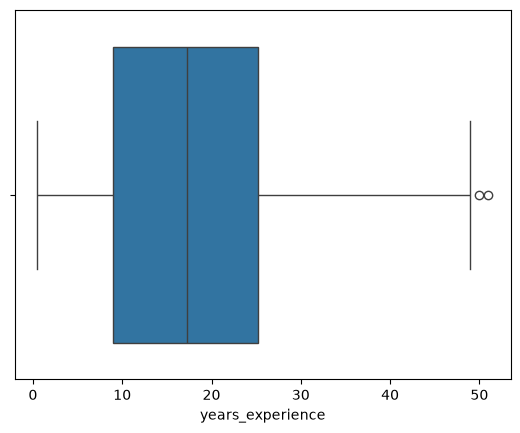

In [15]:
sns.boxplot(x = data["years_experience"])

In [16]:
data[data["years_experience"]>35][['years_experience', 'salary', 'location']]

,years_experience,salary,location
89,36.0,83000,Boston
90,37.0,101000,Chicago
92,38.0,99000,Boston
93,39.0,97000,Seattle
95,40.0,99000,San Francisco
96,41.0,155000,New York
97,42.0,78000,Austin
98,44.0,120000,Chicago
99,45.0,96000,Boston
100,46.0,160000,New York


In [17]:
data = data[data["years_experience"]<=35].reset_index(drop = True)

In [18]:
print(f"Dataset shape after filtering: {data.shape}")

Dataset shape after filtering: (85, 9)


##### Years of experience vs Salary

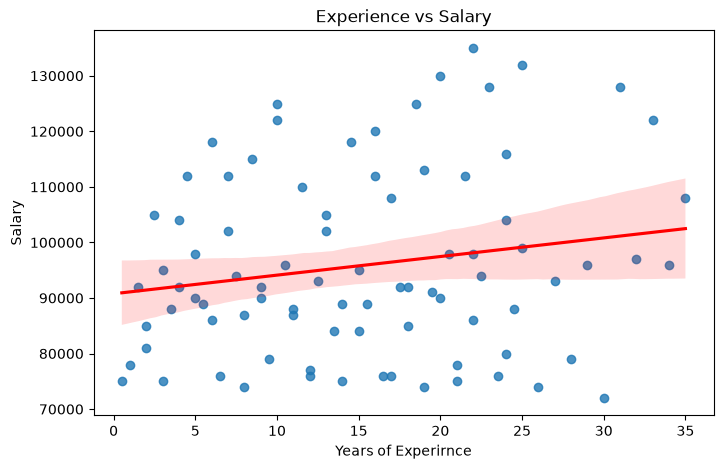

In [19]:
plt.figure(figsize=(8,5))
sns.regplot(data = data,x = "years_experience", y = "salary",line_kws = {"color":"red"})
plt.title("Experience vs Salary")
plt.xlabel("Years of Experirnce")
plt.ylabel("Salary")
plt.show()

#### Preprocessing and Data Leakage prevebtion

In [20]:
# One-hot Encode Locations
df_encode = pd.get_dummies(data,columns = ["location"],drop_first=True, dtype = int)

In [21]:
df_encode

,years_experience,education_level,skill_python,skill_sql,skill_aws,skill_cloud,company_size,salary,location_Boston,location_Chicago,location_Mountain View,location_New York,location_San Francisco,location_Seattle
0,0.5,1,0.85,0.60,0.40,0.30,1,75000,0,0,1,0,0,0
1,1.0,1,0.90,0.65,0.45,0.35,1,78000,0,0,0,0,0,0
2,1.5,2,0.92,0.70,0.50,0.45,2,92000,0,0,0,0,0,1
3,2.0,1,0.88,0.68,0.48,0.42,1,81000,0,0,0,0,0,0
4,2.5,2,0.95,0.75,0.60,0.55,3,105000,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,31.0,3,0.99,0.84,0.75,0.72,3,128000,0,1,0,0,0,0
81,32.0,2,0.94,0.78,0.63,0.58,2,97000,1,0,0,0,0,0
82,33.0,3,0.97,0.81,0.71,0.64,3,122000,0,0,0,1,0,0
83,34.0,2,0.92,0.74,0.58,0.50,2,96000,0,0,0,0,0,1


##### "Note: Location was one-hot encoded with drop_first=True. 'Austin' serves as the reference category; all location coefficients represent the salary premium or discount relative to Austin."

In [22]:
data["location"].unique()

<StringArray>
['Mountain View',        'Austin',       'Seattle', 'San Francisco',
      'New York',        'Boston',       'Chicago']
Length: 7, dtype: str

In [23]:
# 1. Create ONE composite skill score from ALL four skills
df_encode['tech_skill_score'] = (
    df_encode['skill_python'] + 
    df_encode['skill_cloud'] + 
    df_encode['skill_aws'] + 
    df_encode['skill_sql']
) / 4

# 2. Drop ALL original skill columns + salary
X = df_encode.drop(columns=[
    "salary", 
    "skill_python", "skill_cloud", "skill_aws", "skill_sql"
])

# 3. Target stays the same
Y = df_encode["salary"]
Y = np.log1p(Y)

# 4. Split stays the same
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#### Feature Scaling

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X.columns)

## Methodology: Regularization & Transformation
Before trusting the model outputs, several crucial statistical hurdles were addressed:

1. **Log-Transformation of Salary:** We applied a `log1p` transformation to the target variable (`salary`). Salary data naturally suffers from heteroscedasticity (variance increases as salary increases). The log transform stabilization ensures the linear regression model isn't disproportionately skewed by high-earning outliers.
2. **Variance Inflation Factor (VIF):** Real-world skill variables often suffer from severe multicollinearity. We utilized VIF to diagnose these redundancies and merged skills into a single `tech_skill_score` to prevent unstable coefficients.
3. **Lasso Regression (L1 Regularization):** We compared standard OLS (Linear Regression) alongside Ridge and Lasso. Lasso was ultimately used for automated feature selection, elegantly driving weak or redundant predictors exactly to zero.


#### Model Training (Baseline + Regularization)

In [25]:
# 1. Baseline
lr = LinearRegression().fit(X_train_scaled,Y_train)

# 2. Ridge (Handles Multicolinearity)
ridge = RidgeCV(alphas = np.logspace(-2,3,50), cv = 5).fit(X_train_scaled,Y_train)

# 3. Lasso (Performs feature selection)
lasso = LassoCV(alphas = np.logspace(-2,3,50), cv = 5).fit(X_train_scaled,Y_train)

In [26]:
models = [lr,ridge,lasso]
names = ["LR","Ridge","Lasso"]
results = []

for model, name in zip(models,names):
    # Predictions come out in logspace
    Y_train_pred_log = model.predict(X_train_scaled)
    Y_test_pred_log = model.predict(X_test_scaled)
    
    # Invert : np.expm1 is the exact inverse of np.log1p
    Y_train_pred = np.expm1(Y_train_pred_log)
    Y_test_pred = np.expm1(Y_test_pred_log)
    
    # y_train / y_test in the notebook are currently in log-space,
    # so invert them too (or re-read the original salary column)
    Y_train_actual = np.expm1(Y_train)
    Y_test_actual = np.expm1(Y_test)
    
    results.append({
        "Model" : name,
        "Train R2":r2_score(Y_train_actual,Y_train_pred),
        "Test R2" : r2_score(Y_test_actual,Y_test_pred),
        "Test RMSE" : np.sqrt(mean_squared_error(Y_test_actual,Y_test_pred)),
        "Test MAE" : mean_absolute_error(Y_test_actual,Y_test_pred)
    })
    
results_df = pd.DataFrame(results)
display(results_df)

,Model,Train R2,Test R2,Test RMSE,Test MAE
0,LR,0.972849,0.872228,4820.917787,3967.810331
1,Ridge,0.972461,0.874601,4775.931073,3932.364514
2,Lasso,0.960691,0.895323,4363.520859,3334.984968


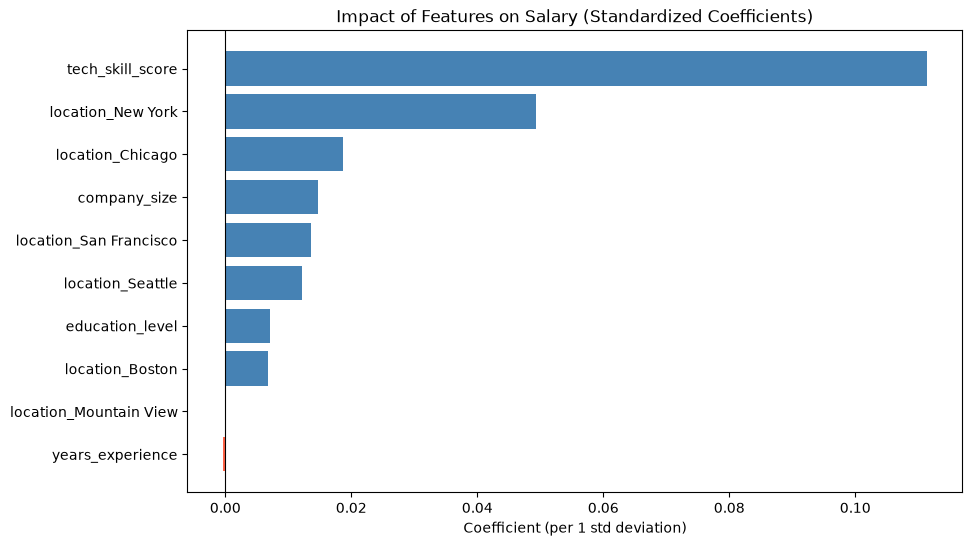

In [27]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_}).sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=['steelblue' if c >= 0 else 'tomato' for c in coef_df['Coefficient']])
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.title("Impact of Features on Salary (Standardized Coefficients)")
plt.xlabel("Coefficient (per 1 std deviation)")
plt.ylabel("")
plt.show()

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_train_scaled.values, i) 
            for i in range(X_train_scaled.shape[1])]
})
print(vif_data.sort_values(by='VIF', ascending=False))

                  Feature        VIF
9        tech_skill_score  13.929324
1         education_level  11.438608
2            company_size   6.865360
6       location_New York   4.732310
4        location_Chicago   2.263300
7  location_San Francisco   2.153270
3         location_Boston   1.702715
8        location_Seattle   1.681263
5  location_Mountain View   1.344827
0        years_experience   1.264682


In [29]:
print(pd.DataFrame({'Feature': X.columns, 'Coef': lasso.coef_}).sort_values('Coef'))

                  Feature      Coef
0        years_experience  0.000000
3         location_Boston -0.000000
5  location_Mountain View -0.000000
4        location_Chicago  0.000000
7  location_San Francisco  0.000000
8        location_Seattle  0.000000
1         education_level  0.015863
2            company_size  0.015906
6       location_New York  0.022050
9        tech_skill_score  0.114628


#### Selected features

In [31]:
import numpy as np

# use a tolerance instead of != 0
coef = np.array(lasso.coef_).ravel()

mask = np.abs(coef) > 1e-6

# IMPORTANT: X must be the same feature DataFrame used to fit the lasso
selected = X.columns[mask]
selected

Index(['education_level', 'company_size', 'location_New York',
       'tech_skill_score'],
      dtype='str')

In [33]:
X_train_final = X_train_scaled[selected]
X_test_final = X_test_scaled[selected]

print(f"Original feature count : {X_train_scaled.shape[1]}")
print(f"Selected feature count : {X_train_final.shape[1]}")

Original feature count : 10
Selected feature count : 4


#### Final Linear Regression model

In [35]:
final_model = LinearRegression()
final_model.fit(X_train_final,Y_train)

# Get predictions(still in logspace)
Y_pred_log = final_model.predict(X_test_final)
Y_train_pred_log1 = final_model.predict(X_train_final)

# Convert the log into dollars
Y_pred = np.expm1(Y_pred_log)
Y_train_pred = np.expm1(Y_train_pred_log1)
Y_test_actual = np.expm1(Y_test)
Y_train_actual = np.expm1(Y_train)

#### Model Evaluation

In [36]:
final_test_r2 = r2_score(Y_test_actual, Y_pred)
final_train_r2 = r2_score(Y_train_actual, Y_train_pred)

print(f"Final Train R²: {final_train_r2:.4f}")
print(f"Final Test R²:  {final_test_r2:.4f}")
print(f"Final Test MAE: ${mean_absolute_error(Y_test_actual, Y_pred):,.2f}")

Final Train R²: 0.9672
Final Test R²:  0.8670
Final Test MAE: $3,870.13


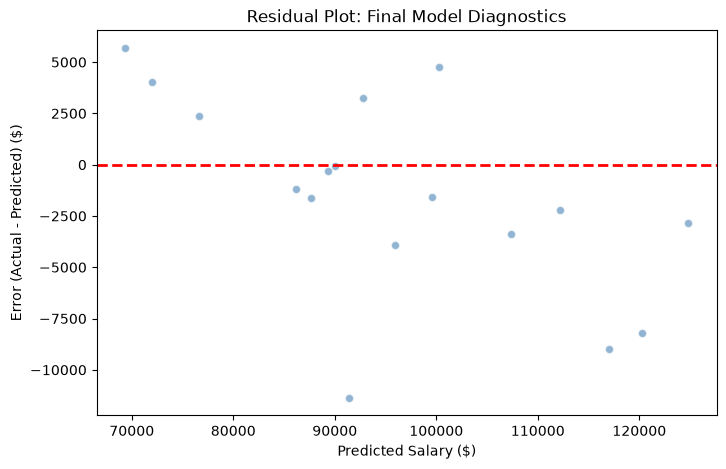

In [38]:
residuals = Y_test_actual - Y_pred
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title("Residual Plot: Final Model Diagnostics")
plt.xlabel("Predicted Salary ($)")
plt.ylabel("Error (Actual - Predicted) ($)")
plt.show()

## Key Findings & Business Insights
Based on the final Lasso-selected feature set and their coefficients, we can conclude:

1. **Tech Skills Dominate:** The constructed `tech_skill_score` is the single most powerful driver of compensation.
2. **Location Premium:** Being based in **New York** provides a statistically significant salary premium over the baseline reference city (Austin).
3. **Education & Scale:** Higher education levels and larger company sizes act as steady, independent positive multipliers for compensation.
4. **Experience is Confounded:** Interestingly, raw tenure (years of experience) was driven to zero by Lasso. Once actual technical skills and roles were accounted for, raw "time in seat" added no independent predictive value in this dataset.

## Limitations
* **Small Sample Size:** This dataset consists of fewer than 100 observations after anomaly removal. The insights are illustrative and intended for demonstration purposes; a production model would require thousands of rows.
* **Synthetic / Unobserved Variables:** The data lacks variables like equity/stock options, sign-on bonuses, and exact specific tech stacks (e.g., React vs. Angular), which historically make up a large portion of total compensation.
